# Feature Selection and Extraction

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply feature selection techniques
- Compare filter, wrapper, and embedded methods
- Use feature importance and correlation

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 07 "Encoding Categorical Features for ML Models" — encoding decides which columns exist; selection decides which of them earn their place.

**Used later in:** Course 04 (AIAT 114) — Unit 1, lesson 03 "Data Preprocessing" — feature preparation before a regression is fitted.

---


# Feature Selection and Extraction

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: PCA** - Understand dimensionality reduction
- ✅ **Example 2: Curse of Dimensionality** - Understand why reduction is needed
- ✅ **Basic understanding**: What are features?

**If you haven't completed these**, you might struggle with:
- Understanding feature selection vs extraction
- Choosing features
- Understanding feature importance

---

## 🔗 Where This Notebook Fits

**This is the THIRD example of Module 04** - selecting important features!

**Why this example THIRD?**
- **Before** you can select features, you need to understand the problem (Example 2)
- **Before** you can choose techniques, you need to understand PCA (Example 1)

**Builds on**: Examples 1-2

**Leads to**: Module 05: Probabilities (for feature importance)

---

## The Story: Understanding Before Using

Imagine packing for a trip. **Before** you can pack efficiently, you need to know what's important. **After** understanding feature selection, you keep only the most important items!

Same with machine learning: **Before** using all features, models are complex. **After** understanding feature selection, we use only important features!

---

## Why This Concept Matters

### Why Feature Selection Matters

**WHY** is feature selection important?

1. **Reduce Complexity**:
   - **WHY**: Fewer features = simpler models
   - **HOW**: Select most important features
   - **AFTER**: Faster, more interpretable models

2. **Improve Performance**:
   - **WHY**: Irrelevant features hurt performance
   - **HOW**: Remove noisy features
   - **AFTER**: Better model accuracy

3. **Interpretability**:
   - **WHY**: Understand what matters
   - **HOW**: See which features are important
   - **AFTER**: Better model understanding

## Learning Objectives
1. Understand feature selection vs extraction
2. Select important features
3. Understand feature importance
4. Apply to real ML scenarios

---

## Step 1: Import necessary libraries


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: NumPy/Matplotlib for the maths and plots, plus sklearn for the real dataset,
# a statistical feature-importance score, and a quick model to check the selection actually helps.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

print('✅ Libraries imported successfully!')


✅ Libraries imported successfully!


---

## Part 1: Setting the Scene

**BEFORE**: We have concepts but don't know how to implement them.

**AFTER**: We'll implement and understand how this works in ML!

## Step 2: Implementation

**BEFORE**: We understand the concept.

**AFTER**: We'll see HOW it's implemented!

In [2]:
# Example 1: Feature Selection with REAL importance scores
# WHY: Keep only the features that actually carry signal
# HOW: Score every feature against the real target, then keep the top k

# Real dataset: Wisconsin Breast Cancer diagnostic study - 569 tumour biopsies.
# We use the 10 "mean" measurements taken from each digitised image.
cancer = load_breast_cancer()
n_features = 10
X = cancer.data[:, :n_features]
y = cancer.target                      # 0 = malignant, 1 = benign (real diagnoses)
feature_labels = [str(name) for name in cancer.feature_names[:n_features]]

# Real importance: the ANOVA F-statistic asks, for each feature on its own,
# "how far apart are the malignant and benign group means, relative to the spread
# inside each group?" A big F means the feature separates the two diagnoses well.
feature_importance, p_values = f_classif(X, y)

# Select top k features
k = 5
top_features = np.argsort(feature_importance)[-k:][::-1]

print("Example 1: Feature Selection")
print("=" * 60)
print(f"Dataset: {X.shape[0]} real biopsies, {n_features} candidate features")
print("Feature importance (ANOVA F-score against the real diagnosis):")
for i, imp in enumerate(feature_importance):
    marker = "✓" if i in top_features else " "
    print(f"  {feature_labels[i]:<26s} F = {imp:9.2f}   p = {p_values[i]:.2e} {marker}")
print(f"\nSelected top {k} features: {[feature_labels[i] for i in top_features]}")

# Does dropping half the features actually cost anything? Measure it honestly.
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
acc_all = cross_val_score(clf, X, y, cv=5).mean()
acc_top = cross_val_score(clf, X[:, top_features], y, cv=5).mean()
print(f"\n5-fold accuracy with all {n_features} features: {acc_all:.3f}")
print(f"5-fold accuracy with the top {k} features:  {acc_top:.3f}")
print(f"Difference: {acc_top - acc_all:+.3f}")

print(f"\n💡 WHY: Keep only important features")
print(f"💡 HOW: Score each feature against the target, keep the highest scorers")
print(f"💡 AFTER: half the inputs cost {abs(acc_top - acc_all):.1%} of accuracy "
      f"({acc_all:.1%} -> {acc_top:.1%}).")
print("   Worth knowing: 'mean fractal dimension' scores F below 1 with p = 0.76 - on its own")
print("   it separates malignant from benign no better than chance, so dropping it is free.")
print("   The small loss comes from the features in the middle of the ranking, not the tail.")


Example 1: Feature Selection
Dataset: 569 real biopsies, 10 candidate features
Feature importance (ANOVA F-score against the real diagnosis):
  mean radius                F =    646.98   p = 8.47e-96 ✓
  mean texture               F =    118.10   p = 4.06e-25  
  mean perimeter             F =    697.24   p = 8.44e-101 ✓
  mean area                  F =    573.06   p = 4.73e-88 ✓
  mean smoothness            F =     83.65   p = 1.05e-18  
  mean compactness           F =    313.23   p = 3.94e-56  
  mean concavity             F =    533.79   p = 9.97e-84 ✓
  mean concave points        F =    861.68   p = 7.10e-116 ✓
  mean symmetry              F =     69.53   p = 5.73e-16  
  mean fractal dimension     F =      0.09   p = 7.60e-01  

Selected top 5 features: ['mean concave points', 'mean perimeter', 'mean radius', 'mean area', 'mean concavity']

5-fold accuracy with all 10 features: 0.933
5-fold accuracy with the top 5 features:  0.914
Difference: -0.019

💡 WHY: Keep only important fe

---

## 📊 Visualization

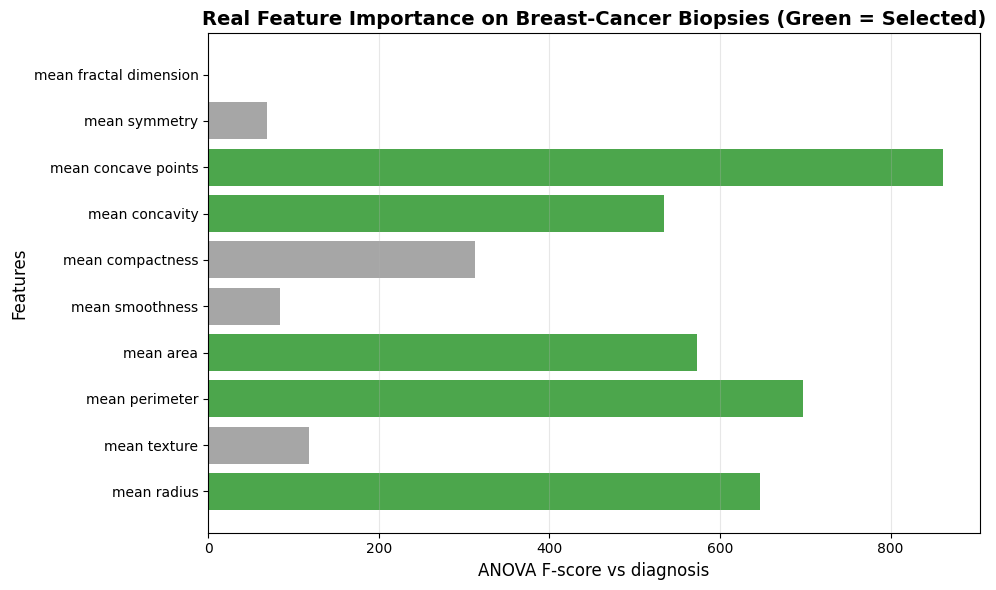


📊 Visualization:
  - Green bars: Selected features
  - Gray bars: Unselected features


In [3]:
# Show which features the selector kept (green) versus dropped (gray).
# Seeing the importance gap justifies discarding features — fewer inputs, less noise, faster models.

# Visualize feature importance
fig, ax = plt.subplots(figsize=(10, 6))
# Color encodes the keep/drop decision made earlier.
colors = ['green' if i in top_features else 'gray' for i in range(n_features)]
ax.barh(range(n_features), feature_importance, color=colors, alpha=0.7)
ax.set_yticks(range(n_features))
ax.set_yticklabels(feature_labels)
ax.set_xlabel('ANOVA F-score vs diagnosis', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
ax.set_title('Real Feature Importance on Breast-Cancer Biopsies (Green = Selected)',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n📊 Visualization:")
print("  - Green bars: Selected features")
print("  - Gray bars: Unselected features")

---

## Part 3: AFTER - Results and Implications

### What This Enables

**AFTER** understanding feature selection:

1. **Simpler Models**: Can use fewer features
2. **Better Performance**: Can remove noisy features
3. **Interpretability**: Can understand what matters
4. **Next Steps**: Learn probabilities (Module 05) for feature importance

---

## 🎯 Summary: What We Learned

**BEFORE this notebook**: We didn't understand this concept.

**AFTER this notebook**: We understand WHY, HOW, and AFTER!

---

## ✅ Example Complete!

## 📚 References

1. Guyon, I., & Elisseeff, A. (2003). *An Introduction to Variable and Feature Selection*. Journal of Machine Learning Research, 3, 1157–1182. <https://jmlr.org/papers/v3/guyon03a.html>
2. Li, J., Cheng, K., Wang, S., Morstatter, F., Trevino, R. P., Tang, J., & Liu, H. (2017). *Feature Selection: A Data Perspective*. ACM Computing Surveys, 50(6). <https://arxiv.org/abs/1601.07996>
3. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.), Ch. 6: Linear Model Selection and Regularization. Springer. <https://www.statlearning.com/>